# 04 · Modelado y diseño experimental

**Proyecto:** Identificación de hogares en situación de pobreza monetaria mediante aprendizaje automático (ENAHO 2025).

Este cuaderno corresponde a la **Fase 4 de CRISP-DM: Modelado** y responde al objetivo específico **OE3**: diseñar e implementar modelos de aprendizaje automático para identificar hogares pobres.

**Entrada:** el dataset de hogares y la partición del cuaderno 03 (solo el conjunto de entrenamiento). **Salida:** los cinco modelos entrenados (`models/`) y la tabla comparativa de la validación cruzada (`results/tablas/`).

Contenido:

1. diseño del modelo: tipo de problema, algoritmos, funciones de pérdida y estrategia de validación;
2. métrica principal y regla de selección, definidas **antes** de ver los resultados;
3. baseline sin IA (regla "rural = pobre");
4. diseño experimental;
5. experimentos E1 a E5 con validación cruzada y `GridSearchCV`;
6. comparación de modelos y selección preliminar;
7. guardado de los modelos entrenados.

> **Importante:** en este cuaderno **no se usa el conjunto de prueba**. Todas las decisiones se toman con validación cruzada dentro del conjunto de entrenamiento. El conjunto de prueba se usa una sola vez, en el cuaderno 05.

In [1]:
# ==========================================================
# CONFIGURACIÓN DEL ENTORNO (funciona en Google Colab y en local)
# ==========================================================
# En Colab, la primera vez conviene instalar las versiones del proyecto y reiniciar la sesión:
# !pip install -r /content/drive/MyDrive/proyecto-pobreza-ia/requirements.txt
import os
import sys

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    # En Colab: montamos Google Drive y nos ubicamos en la carpeta del proyecto
    from google.colab import drive
    drive.mount("/content/drive")
    RUTA_PROYECTO = "/content/drive/MyDrive/proyecto-pobreza-ia"  # ajustar si el proyecto está en otra carpeta
    os.chdir(RUTA_PROYECTO)
elif os.path.basename(os.getcwd()) == "notebooks":
    # En local: si el notebook se abre desde la carpeta notebooks/, subimos a la raíz
    os.chdir("..")

# Comprobamos que estamos en la raíz del proyecto y permitimos importar su código (carpeta src/)
assert os.path.isdir("src"), "No se encuentra la carpeta src/: revisa RUTA_PROYECTO"
sys.path.insert(0, os.getcwd())
print("Entorno:", "Google Colab" if EN_COLAB else "local", "| Carpeta del proyecto:", os.path.basename(os.getcwd()))

Entorno: local | Carpeta del proyecto: proyecto-pobreza-ia


In [2]:
# Librerías
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

# Código propio del proyecto (carpeta src/)
from src.config import FOLDS_VALIDACION_CRUZADA, RUTA_HOGARES, RUTA_PARTICION, CARPETA_MODELOS
from src.features.construir import VARIABLES_PREDICTORAS, VARIABLE_OBJETIVO
from src.preprocessing.particion import aplicar_particion
from src.models.modelos import crear_pipeline, crear_modelos, GRILLAS, regla_rural
from src.evaluation.metricas import calcular_metricas, evaluar_validacion_cruzada
from src.visualizacion import aplicar_estilo, guardar_figura, AZUL, TEXTO_SECUNDARIO

aplicar_estilo()

hogares = pd.read_csv(RUTA_HOGARES[2025])
entrenamiento, _ = aplicar_particion(hogares, RUTA_PARTICION)  # la prueba NO se usa en este cuaderno

X_entrenamiento = entrenamiento[VARIABLES_PREDICTORAS]
y_entrenamiento = entrenamiento[VARIABLE_OBJETIVO]
print("Entrenamiento:", X_entrenamiento.shape, "| hogares pobres:", int(y_entrenamiento.sum()))

Entrenamiento: (26961, 36) | hogares pobres: 4883


## 1. Diseño del modelo

### 1.1. Tipo de problema

Es un problema de **clasificación binaria supervisada**:

- **Entradas:** 36 características observables del hogar (vivienda, servicios, equipamiento, composición, educación y ubicación), que el preprocesador convierte en 119 columnas.
- **Salida:** `pobre` (1 = pobre extremo o no extremo según el INEI; 0 = no pobre).
- **Unidad:** el hogar.

El modelo entrega además una **probabilidad** de que el hogar sea pobre. Esa probabilidad permite ordenar a los hogares por prioridad, algo útil en el prototipo.

### 1.2. Algoritmos seleccionados y por qué

Se comparan **cuatro familias de algoritmos vistas en el curso**, que aprenden de maneras distintas. Así se puede saber qué tipo de patrón explica mejor la pobreza:

| Algoritmo | Cómo aprende | Por qué es apropiado para este problema | Riesgo principal |
|---|---|---|---|
| **Regresión logística** (cuaderno 06 del curso) | Combina linealmente las variables para estimar la probabilidad (log-odds) de ser pobre | Calcula un puntaje lineal, como los *proxy means tests* usados en focalización; interpretable; rápida | No captura interacciones no lineales si no se crean a mano |
| **Árbol de decisión** (cuaderno 08 del curso) | Aprende reglas "si… entonces…" dividiendo los datos por umbrales | Captura interacciones (por ejemplo, el piso de tierra pesa distinto en Lima que en la sierra rural); fácil de explicar | Sobreajuste si crece demasiado |
| **KNN** (cuaderno 07 del curso) | Clasifica un hogar según la clase de los *k* hogares más parecidos | Idea intuitiva: hogares con características similares tienen condiciones similares | Sensible a la escala y a la alta dimensión; no tiene balanceo de clases |
| **Random Forest** (cuaderno 08 del curso) | Promedia muchos árboles entrenados con muestras y variables aleatorias | Reduce la varianza de un árbol solo; robusto a atípicos y variables correlacionadas; muy efectivo en datos tabulares | Menos interpretable que un árbol; más costoso |

**Alternativas consideradas y descartadas:**

- **Regresión lineal** (cuaderno 05 del curso): es el enfoque clásico de los *proxy means tests*, que predicen el gasto del hogar. Pero minimiza el error en todo el rango del gasto, y no los errores de clasificación cerca de la línea de pobreza, que son los que importan en focalización; la evidencia muestra que así se excluye a muchos pobres. Además, la tarea aquí es reproducir la clasificación oficial (sí/no), no el monto del gasto.
- **K-Means** (cuaderno 09 del curso): es no supervisado. Aquí sí contamos con la etiqueta oficial del INEI, así que corresponde un método supervisado.
- **XGBoost, redes neuronales u otros:** no forman parte del curso.

### 1.3. Función de pérdida o criterio de cada algoritmo

| Algoritmo | Qué optimiza |
|---|---|
| Regresión logística | **Pérdida logarítmica (entropía cruzada binaria)** con regularización L2, cuya intensidad controla `C` (menor `C` = más regularización) |
| Árbol de decisión | **Impureza de Gini**: en cada división busca los grupos más "puros" en cuanto a la clase |
| Random Forest | **Impureza de Gini** en cada árbol; la predicción final es el promedio de los árboles |
| KNN | No tiene función de pérdida: no "entrena" parámetros, sino que memoriza los hogares y mide distancias (euclidiana) al predecir |

### 1.4. Estrategia de entrenamiento y validación

- **Mismo pipeline para todos:** preprocesamiento (cuaderno 03) + modelo, dentro de un `Pipeline`.
- **Desbalance de clases:** se prueba `class_weight="balanced"` como hiperparámetro en regresión logística, árbol y Random Forest (cuaderno 06 del curso). Da más peso a los errores en la clase minoritaria (pobre). KNN no tiene esta opción.
- **Búsqueda de hiperparámetros:** `GridSearchCV` (cuaderno 10 del curso) con **validación cruzada de 5 particiones** sobre el conjunto de entrenamiento. Como la salida es de clasificación, scikit-learn usa particiones **estratificadas**, y son **las mismas para todos los modelos**. Así se comparan en igualdad de condiciones.
- **Umbral de decisión:** se usa **0,5 para todos los modelos**. El análisis de cómo cambia el balance entre errores al mover el umbral se hace en el cuaderno 05.
- **Semilla fija:** `random_state=42` en todos los procesos aleatorios.

## 2. Métrica principal y regla de selección (definidas antes de ver resultados)

**Métrica principal: F1 de la clase "pobre".** En focalización hay dos errores con costo real:

- **error de exclusión** (falso negativo): un hogar pobre queda fuera del programa. Lo mide el *recall*;
- **error de inclusión o filtración** (falso positivo): un hogar no pobre recibe la ayuda y consume recursos. Lo mide la *precision*.

El F1 es la media armónica de ambos: solo es alto si los dos lo son. El *accuracy* **no** es adecuado, porque premia predecir "no pobre" (81,9 % de los hogares). Se reportan también *precision*, *recall*, *ROC-AUC* (capacidad de ordenar hogares por riesgo, independiente del umbral) y *accuracy*.

**Regla de selección:** se elige el modelo con mayor F1 medio en la validación cruzada. Si la diferencia con el segundo es **menor que la desviación estándar entre particiones**, se considera un empate práctico y se prefiere el modelo **más interpretable**, porque en una política social es importante poder explicar por qué se prioriza a un hogar.

## 3. Baseline sin IA: la regla "rural = pobre" (E0)

Antes de entrenar modelos, medimos qué se logra **sin inteligencia artificial**, con una regla simple y fácil de aplicar: considerar pobre a todo hogar rural. Es una forma de **focalización geográfica** muy común. También calculamos el caso trivial de "predecir que nadie es pobre", para mostrar por qué el accuracy engaña.

In [3]:
# E0: regla rural aplicada a los hogares de entrenamiento (no requiere entrenamiento)
metricas_regla = calcular_metricas(y_entrenamiento, regla_rural(X_entrenamiento))

# Caso trivial: predecir "no pobre" para todos
metricas_nadie = calcular_metricas(y_entrenamiento, np.zeros(len(y_entrenamiento), dtype=int))

pd.DataFrame({"Regla 'rural = pobre' (E0)": metricas_regla,
              "Predecir 'nadie es pobre'": metricas_nadie}).T.round(3)

,accuracy,precision,recall,f1
Regla 'rural = pobre' (E0),0.657,0.265,0.504,0.347
Predecir 'nadie es pobre',0.819,0.000,0.000,0.000


### Interpretación del baseline

- **Regla "rural = pobre" (E0):** F1 = **0,347**.
  - Su *precision* es 0,265: de cada 4 hogares rurales que la regla marca como pobres, solo 1 lo es.
  - Su *recall* es 0,504: deja fuera a la **mitad de los hogares pobres**, casi todos urbanos.
  - Es el resultado que un modelo de IA debe superar con claridad para justificar su uso.
- **Predecir "nadie es pobre":** tiene el **accuracy más alto (0,819)** y, sin embargo, **no identifica a ningún hogar pobre** (F1 = 0). Esto demuestra por qué el accuracy no puede ser la métrica de este proyecto.

## 4. Diseño experimental

| Experimento | Modelo | Variables | Hiperparámetros | Métrica | Pregunta que responde |
|---|---|---|---|---|---|
| **E0** | Regla "rural = pobre" | `area_rural` | — | F1 | ¿Cuánto se logra sin IA? |
| **E1** | Regresión logística | 36 | Por defecto (`C=1`, sin balanceo) | F1 (VC 5) | ¿Cuánto aporta un modelo de ML sin ajustar? |
| **E2** | Regresión logística | 36 | Ajustados con `GridSearchCV` | F1 (VC 5) | ¿Cuál es el mejor modelo lineal? |
| **E3** | Árbol de decisión | 36 | Ajustados con `GridSearchCV` | F1 (VC 5) | ¿Ayudan las reglas no lineales interpretables? |
| **E4** | KNN | 36 | Ajustados con `GridSearchCV` | F1 (VC 5) | ¿Sirve la similitud entre hogares? |
| **E5** | Random Forest | 36 | Ajustados con `GridSearchCV` | F1 (VC 5) | ¿Mejora un ensamble no lineal? |
| **E6** | Mejor modelo | 36 | Los seleccionados | F1 en prueba y en ENAHO 2025 (hogares nuevos) | ¿Generaliza a datos no vistos y a otro año? (cuaderno 05) |

- **Qué cambia:** el algoritmo y sus hiperparámetros.
- **Qué permanece constante:** las 36 variables, el preprocesamiento, la partición de entrenamiento, las 5 particiones de la validación cruzada, el umbral de 0,5, la métrica principal y la semilla.
- **Qué se mide:** F1 (principal), *precision*, *recall*, *ROC-AUC* y *accuracy*, como media y desviación estándar en las 5 particiones.
- **Por qué:** para atribuir cualquier diferencia de desempeño **únicamente al algoritmo**, y no a diferencias en los datos o en la preparación.

## 5. Experimentos

### E1. Regresión logística con hiperparámetros por defecto (baseline de ML)

In [4]:
modelos = crear_modelos()
resultados_cv = {}      # métricas de validación cruzada por experimento
mejores_modelos = {}    # pipelines entrenados
hiperparametros = {}    # mejores hiperparámetros encontrados
tiempos = {}            # segundos de búsqueda y entrenamiento

inicio = time.time()
pipeline_e1 = crear_pipeline(modelos["Regresión logística"])
resultados_cv["E1 Regresión logística (defecto)"] = evaluar_validacion_cruzada(pipeline_e1, X_entrenamiento, y_entrenamiento)
tiempos["E1 Regresión logística (defecto)"] = time.time() - inicio
hiperparametros["E1 Regresión logística (defecto)"] = "C=1, class_weight=None"

resultados_cv["E1 Regresión logística (defecto)"].round(3).to_frame("E1").T

,f1_media,f1_desv,precision_media,precision_desv,recall_media,recall_desv,roc_auc_media,roc_auc_desv,accuracy_media,accuracy_desv
E1,0.443,0.021,0.633,0.024,0.341,0.019,0.859,0.006,0.845,0.005


### Interpretación de E1

- Sin ningún ajuste, la regresión logística ya supera a la regla rural en F1: **0,443 frente a 0,347**.
- Pero su *recall* es solo **0,341**: deja fuera a 2 de cada 3 hogares pobres. Como los pobres son minoría (18 %), el modelo sin balanceo solo se "atreve" a marcar como pobres a los casos muy claros. Por eso su *precision* es alta (0,633) y su *recall*, bajo.
- Su **ROC-AUC es 0,859**. Es decir, el modelo ya **sabe ordenar** bien a los hogares por riesgo: el problema no es su capacidad de distinguir, sino el punto de corte con que decide.
- Tiene el *accuracy* más alto de los modelos (0,845) y aun así pierde a la mayoría de los pobres. Es otra muestra de que el accuracy engaña en este problema.

### Función común para los experimentos E2 a E5

Para cada algoritmo, `GridSearchCV` prueba todas las combinaciones de su grilla (definida en `src/models/modelos.py`) con validación cruzada de 5 particiones, y se queda con la de mayor F1. Luego se calculan todas las métricas de esa mejor configuración, con las mismas 5 particiones.

In [5]:
def ejecutar_experimento(codigo, nombre_modelo, n_jobs=-1):
    """Ajusta los hiperparámetros de un algoritmo y registra sus resultados:
    1. GridSearchCV prueba todas las combinaciones de la grilla con validación cruzada de 5 particiones (métrica: F1);
    2. se guarda la mejor configuración, que GridSearchCV reentrena con todo el conjunto de entrenamiento;
    3. se calculan todas sus métricas con las mismas 5 particiones;
    4. se devuelven las 5 mejores combinaciones, para ver qué hiperparámetros importan.
    """
    inicio = time.time()
    busqueda = GridSearchCV(
        crear_pipeline(modelos[nombre_modelo]),
        param_grid=GRILLAS[nombre_modelo],
        cv=FOLDS_VALIDACION_CRUZADA,
        scoring="f1",
        n_jobs=n_jobs,
    )
    busqueda.fit(X_entrenamiento, y_entrenamiento)
    etiqueta = f"{codigo} {nombre_modelo}"

    mejores_modelos[etiqueta] = busqueda.best_estimator_  # reentrenado con todo el conjunto de entrenamiento
    hiperparametros[etiqueta] = ", ".join(f"{k.replace('modelo__', '')}={v}" for k, v in busqueda.best_params_.items())
    resultados_cv[etiqueta] = evaluar_validacion_cruzada(busqueda.best_estimator_, X_entrenamiento, y_entrenamiento, n_jobs=n_jobs)
    tiempos[etiqueta] = time.time() - inicio

    # Las 5 mejores combinaciones de la grilla
    ranking = pd.DataFrame(busqueda.cv_results_)[["params", "mean_test_score", "std_test_score", "rank_test_score"]]
    ranking["params"] = ranking["params"].apply(lambda p: {k.replace("modelo__", ""): v for k, v in p.items()})
    print(f"{etiqueta} | combinaciones probadas: {len(ranking)} | tiempo: {tiempos[etiqueta]:.0f} s")
    print("Mejores hiperparámetros:", hiperparametros[etiqueta])
    return ranking.sort_values("rank_test_score").head(5).round(4)

### E2. Regresión logística ajustada

- `C` controla la regularización: valores bajos simplifican el modelo y valores altos lo dejan ajustarse más a los datos.
- `class_weight` decide si se compensa el desbalance de clases.

In [6]:
ejecutar_experimento("E2", "Regresión logística")

E2 Regresión logística | combinaciones probadas: 8 | tiempo: 20 s
Mejores hiperparámetros: C=1, class_weight=balanced


,params,mean_test_score,std_test_score,rank_test_score
5,"{'C': 1, 'class_weight': 'balanced'}",0.5518,0.0103,1
7,"{'C': 10, 'class_weight': 'balanced'}",0.5511,0.0102,2
3,"{'C': 0.1, 'class_weight': 'balanced'}",0.5511,0.0103,3
1,"{'C': 0.01, 'class_weight': 'balanced'}",0.5484,0.0112,4
4,"{'C': 1, 'class_weight': None}",0.4429,0.0208,5


### Interpretación de E2

- La mejor configuración es **`C=1` con `class_weight="balanced"`**: F1 = **0,552 ± 0,010**.
- **El balanceo de clases es el hiperparámetro decisivo.** Las cuatro configuraciones balanceadas obtienen F1 entre 0,548 y 0,552, mientras que sin balanceo el F1 cae a alrededor de 0,44. Al dar más peso a los errores sobre los hogares pobres, el modelo pasa a detectar **8 de cada 10 hogares pobres** (*recall* = 0,801, ver la tabla comparativa).
- La regularización (`C`) casi no influye (de 0,548 a 0,552). Con casi 27 000 hogares y 119 columnas, el riesgo de sobreajuste de un modelo lineal es bajo.
- La contrapartida es la *precision* de 0,421: de cada 10 hogares que el modelo marca como pobres, algo más de 4 lo son. Es el equilibrio entre errores de exclusión e inclusión que se analizará con el umbral en el cuaderno 05.

### E3. Árbol de decisión ajustado

- `max_depth` limita cuántas preguntas encadenadas puede hacer el árbol.
- `min_samples_leaf` exige un mínimo de hogares en cada hoja, para que ninguna regla se base en muy pocos casos.
- Ambos controlan el **sobreajuste**.

In [7]:
ejecutar_experimento("E3", "Árbol de decisión")

E3 Árbol de decisión | combinaciones probadas: 40 | tiempo: 11 s
Mejores hiperparámetros: class_weight=balanced, max_depth=6, min_samples_leaf=20


,params,mean_test_score,std_test_score,rank_test_score
25,"{'class_weight': 'balanced', 'max_depth': 6, '...",0.4996,0.0069,1
24,"{'class_weight': 'balanced', 'max_depth': 6, '...",0.4994,0.0070,2
35,"{'class_weight': 'balanced', 'max_depth': 10, ...",0.4992,0.0121,3
26,"{'class_weight': 'balanced', 'max_depth': 6, '...",0.4985,0.0062,4
38,"{'class_weight': 'balanced', 'max_depth': 12, ...",0.4984,0.0094,5


### Interpretación de E3

- El mejor árbol tiene **profundidad 6, al menos 20 hogares por hoja y balanceo de clases**: F1 = **0,500 ± 0,007**.
- Árboles más profundos no mejoran: profundidades de 10 o 12, con hojas de 50 o 100 hogares, obtienen prácticamente lo mismo (≈ 0,498). Un árbol de 6 niveles ya captura lo que un árbol individual puede aprender.
- Supera a la regla rural y a la regresión logística sin ajustar, pero **queda por debajo de la regresión logística ajustada**. Un árbol asigna la misma probabilidad a todos los hogares de una hoja, y esas "escaleras" de probabilidad ordenan peor a los hogares (ROC-AUC = 0,813, frente a 0,860 de la regresión logística).
- Su ventaja sigue siendo la **interpretabilidad**: sus reglas pueden leerse directamente.

### E4. KNN ajustado

- `n_neighbors` define cuántos hogares parecidos "votan".
- `weights="distance"` da más peso a los más cercanos.
- Se prueban valores impares de *k* para evitar empates.

In [8]:
ejecutar_experimento("E4", "KNN")

E4 KNN | combinaciones probadas: 10 | tiempo: 14 s
Mejores hiperparámetros: n_neighbors=3, weights=distance


,params,mean_test_score,std_test_score,rank_test_score
1,"{'n_neighbors': 3, 'weights': 'distance'}",0.3969,0.0245,1
0,"{'n_neighbors': 3, 'weights': 'uniform'}",0.3962,0.0248,2
2,"{'n_neighbors': 5, 'weights': 'uniform'}",0.3962,0.0195,3
3,"{'n_neighbors': 5, 'weights': 'distance'}",0.3958,0.0198,4
5,"{'n_neighbors': 15, 'weights': 'distance'}",0.3672,0.0126,5


### Interpretación de E4

- KNN es el modelo de ML con **peor desempeño**: F1 = **0,397 ± 0,024** con `k=3` y pesos por distancia. Solo supera a la regla rural y queda por debajo incluso de la regresión logística sin ajustar.
- El F1 **empeora al aumentar *k*** (0,397 con 3 vecinos, 0,367 con 15 y 0,350 con 25). Al consultar más vecinos, la votación queda dominada por la clase mayoritaria (no pobre).
- Hay dos razones de fondo:
  1. **KNN no tiene balanceo de clases**: la mayoría de los vecinos de cualquier hogar son no pobres, así que el *recall* es bajo (0,347).
  2. **La alta dimensión**: con 119 columnas, 93 de ellas 0/1 del One-Hot Encoding, las distancias entre hogares se vuelven poco informativas. Por eso su ROC-AUC (0,727) es el más bajo.
- Es un resultado útil para la discusión: **la idea de similitud entre hogares no basta** si no se controla el desbalance y la dimensión.

### E5. Random Forest ajustado

- Se fijan **300 árboles**: más árboles no causan sobreajuste, solo aumentan el tiempo.
- Se ajustan la profundidad máxima, el mínimo de hogares por hoja y el balanceo de clases.
- Por su costo, la búsqueda se paraleliza dentro del propio Random Forest (`n_jobs=-1` en el modelo).

In [9]:
ejecutar_experimento("E5", "Random Forest", n_jobs=1)

E5 Random Forest | combinaciones probadas: 18 | tiempo: 95 s
Mejores hiperparámetros: class_weight=balanced, max_depth=20, min_samples_leaf=5


,params,mean_test_score,std_test_score,rank_test_score
13,"{'class_weight': 'balanced', 'max_depth': 20, ...",0.5517,0.0143,1
16,"{'class_weight': 'balanced', 'max_depth': None...",0.5499,0.0157,2
14,"{'class_weight': 'balanced', 'max_depth': 20, ...",0.5458,0.0121,3
17,"{'class_weight': 'balanced', 'max_depth': None...",0.5456,0.0121,4
9,"{'class_weight': 'balanced', 'max_depth': 12, ...",0.5425,0.0118,5


### Interpretación de E5

- El mejor Random Forest usa **balanceo de clases, profundidad máxima 20 y al menos 5 hogares por hoja**: F1 = **0,552 ± 0,014**.
- Las 6 mejores configuraciones usan balanceo de clases, lo que confirma lo observado en la regresión logística.
- Frente a un solo árbol, el ensamble mejora claramente (0,552 frente a 0,500): promediar 300 árboles reduce la varianza y produce probabilidades más finas.
- Es el experimento más costoso: **95 segundos** de búsqueda, frente a 20 de la regresión logística.

## 6. Comparación de modelos

La siguiente tabla resume la validación cruzada de todos los experimentos. La regla rural (E0) se incluye con sus métricas sobre el conjunto de entrenamiento, porque no se entrena.

In [10]:
comparacion = pd.DataFrame(resultados_cv).T
columnas = ["f1_media", "f1_desv", "precision_media", "recall_media", "roc_auc_media", "roc_auc_desv", "accuracy_media"]
comparacion = comparacion[columnas]
comparacion.loc["E0 Regla 'rural = pobre'"] = [metricas_regla["f1"], np.nan, metricas_regla["precision"],
                                                metricas_regla["recall"], np.nan, np.nan, metricas_regla["accuracy"]]
comparacion["hiperparametros"] = pd.Series(hiperparametros)
comparacion["tiempo_s"] = pd.Series(tiempos).round(0)
comparacion = comparacion.sort_values("f1_media", ascending=False)

os.makedirs("results/tablas", exist_ok=True)
comparacion.to_csv("results/tablas/04_comparacion_validacion_cruzada.csv")
comparacion.round(3)

,f1_media,f1_desv,precision_media,recall_media,roc_auc_media,roc_auc_desv,accuracy_media,hiperparametros,tiempo_s
E2 Regresión logística,0.552,0.010,0.421,0.801,0.860,0.007,0.764,"C=1, class_weight=balanced",20.0
E5 Random Forest,0.552,0.014,0.465,0.679,0.853,0.008,0.800,"class_weight=balanced, max_depth=20, min_sampl...",95.0
E3 Árbol de decisión,0.500,0.007,0.369,0.775,0.813,0.004,0.719,"class_weight=balanced, max_depth=6, min_sample...",11.0
E1 Regresión logística (defecto),0.443,0.021,0.633,0.341,0.859,0.006,0.845,"C=1, class_weight=None",4.0
E4 KNN,0.397,0.024,0.464,0.347,0.727,0.011,0.809,"n_neighbors=3, weights=distance",14.0
E0 Regla 'rural = pobre',0.347,NaN,0.265,0.504,NaN,NaN,0.657,NaN,NaN


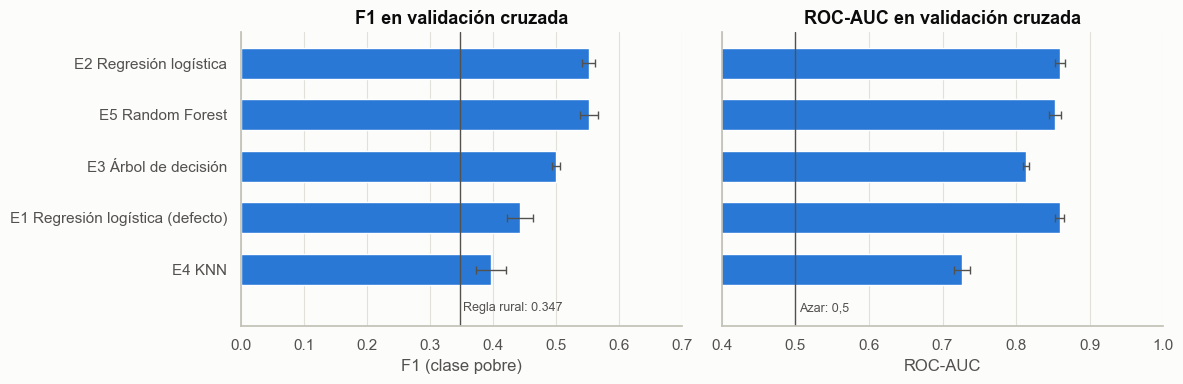

In [11]:
# Gráfico: F1 y ROC-AUC en validación cruzada (media ± desviación estándar)
modelos_ml = comparacion.drop(index="E0 Regla 'rural = pobre'").sort_values("f1_media")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
ax1.barh(modelos_ml.index, modelos_ml["f1_media"], xerr=modelos_ml["f1_desv"], color=AZUL, height=0.6,
         error_kw={"ecolor": TEXTO_SECUNDARIO, "capsize": 3, "linewidth": 1})
ax1.axvline(metricas_regla["f1"], color=TEXTO_SECUNDARIO, linewidth=1)
ax1.set_ylim(-1.1, len(modelos_ml) - 0.4)
ax1.text(metricas_regla["f1"] + 0.005, -0.8, f"Regla rural: {metricas_regla['f1']:.3f}", color=TEXTO_SECUNDARIO, fontsize=9)
ax1.set_xlabel("F1 (clase pobre)")
ax1.set_title("F1 en validación cruzada")
ax1.set_xlim(0, 0.7)
ax1.grid(axis="y", visible=False)

ax2.barh(modelos_ml.index, modelos_ml["roc_auc_media"], xerr=modelos_ml["roc_auc_desv"], color=AZUL, height=0.6,
         error_kw={"ecolor": TEXTO_SECUNDARIO, "capsize": 3, "linewidth": 1})
ax2.axvline(0.5, color=TEXTO_SECUNDARIO, linewidth=1)
ax2.text(0.505, -0.8, "Azar: 0,5", color=TEXTO_SECUNDARIO, fontsize=9)
ax2.set_xlabel("ROC-AUC")
ax2.set_title("ROC-AUC en validación cruzada")
ax2.set_xlim(0.4, 1.0)
ax2.grid(axis="y", visible=False)

fig.tight_layout()
guardar_figura("04_comparacion_modelos_cv")
plt.show()

### Interpretación de la comparación

**1. La IA aporta valor frente al baseline.** Todos los modelos de ML superan a la regla rural en F1. Los mejores pasan de **0,347 a 0,552**, una mejora de **0,205 puntos (59 % relativo)**. La regresión logística ajustada detecta 8 de cada 10 hogares pobres, frente a 5 de cada 10 de la regla, y además con mejor *precision* (0,42 frente a 0,27).

**2. Compensar el desbalance es tan importante como elegir el algoritmo.** La misma regresión logística pasa de F1 = 0,443 a 0,552 solo con `class_weight="balanced"`.

**3. Un modelo no lineal más complejo no supera al lineal.** Random Forest (0,552 ± 0,014) y la regresión logística (0,552 ± 0,010) quedan empatados. Esto sugiere que la relación entre las características observables y la pobreza es **mayormente aditiva y monótona**: más artefactos, más educación o mejores materiales reducen la probabilidad de pobreza, sin interacciones complejas que la regresión logística no pueda representar. Además, el One-Hot Encoding le permite asignar un efecto propio a cada categoría.

**4. Mismo F1, distinto tipo de error.**

| Modelo | *Recall* | *Precision* | Consecuencia práctica |
|---|---|---|---|
| Regresión logística | 0,801 | 0,421 | Deja fuera a menos hogares pobres |
| Random Forest | 0,679 | 0,465 | Incluye a menos hogares no pobres |

Ambos llegan al mismo F1 por caminos distintos, y la regresión logística ordena mejor a los hogares por riesgo (ROC-AUC 0,860 frente a 0,853).

**5. Los resultados son estables.** Las desviaciones estándar entre particiones son pequeñas (≤ 0,024 en F1), así que las diferencias entre los grupos de modelos no se deben al azar de la partición.

In [12]:
# Aplicación de la regla de selección definida en la sección 2
ranking_f1 = comparacion.drop(index="E0 Regla 'rural = pobre'").sort_values("f1_media", ascending=False)
primero, segundo = ranking_f1.index[0], ranking_f1.index[1]
diferencia = ranking_f1.loc[primero, "f1_media"] - ranking_f1.loc[segundo, "f1_media"]
desviacion = ranking_f1.loc[primero, "f1_desv"]

print(f"1.º {primero}: F1 = {ranking_f1.loc[primero, 'f1_media']:.3f} ± {desviacion:.3f}")
print(f"2.º {segundo}: F1 = {ranking_f1.loc[segundo, 'f1_media']:.3f}")
print(f"Diferencia: {diferencia:.3f} | ¿Empate práctico (diferencia < desviación)? {diferencia < desviacion}")

1.º E2 Regresión logística: F1 = 0.552 ± 0.010
2.º E5 Random Forest: F1 = 0.552
Diferencia: 0.000 | ¿Empate práctico (diferencia < desviación)? True


### Selección preliminar del modelo

La diferencia de F1 entre la regresión logística y Random Forest es de **0,000**, mucho menor que la desviación estándar entre particiones (0,010). Según la regla definida en la sección 2, es un **empate práctico**, y se prefiere el modelo más interpretable.

**Modelo seleccionado (preliminar): E2, regresión logística con `C=1` y `class_weight="balanced"`**. Además de ser más interpretable, tiene otras ventajas:

- **Interpretabilidad:** cada variable tiene un coeficiente con signo y magnitud, que permite explicar a un hogar o a un funcionario por qué se le prioriza.
- **Menos errores de exclusión:** *recall* de 0,801 frente a 0,679.
- **Mejor capacidad de ordenar hogares por riesgo:** ROC-AUC de 0,860 frente a 0,853.
- **Eficiencia:** entrena en segundos y el modelo guardado ocupa menos de 0,1 MB, frente a 63 MB del Random Forest. Esto facilita su uso en el prototipo.

Random Forest se mantiene como **alternativa principal** y también se evaluará en el conjunto de prueba. La elección se hizo **solo con validación cruzada**: el conjunto de prueba sigue sin tocarse, así que su evaluación en el cuaderno 05 será una estimación honesta.

## 7. Guardado de los modelos entrenados

Guardamos con `joblib` (cuaderno 12 del curso) **el pipeline completo** de cada experimento, es decir, preprocesamiento más modelo, reentrenado con todo el conjunto de entrenamiento. En el cuaderno 05 se cargarán para evaluarlos **una sola vez** en el conjunto de prueba.

In [13]:
os.makedirs(CARPETA_MODELOS, exist_ok=True)

# E1: el pipeline por defecto se entrena ahora con todo el conjunto de entrenamiento
pipeline_e1.fit(X_entrenamiento, y_entrenamiento)
mejores_modelos["E1 Regresión logística (defecto)"] = pipeline_e1

nombres_archivo = {
    "E1 Regresión logística (defecto)": "e1_regresion_logistica_defecto.joblib",
    "E2 Regresión logística": "e2_regresion_logistica.joblib",
    "E3 Árbol de decisión": "e3_arbol_decision.joblib",
    "E4 KNN": "e4_knn.joblib",
    "E5 Random Forest": "e5_random_forest.joblib",
}
for etiqueta, archivo in nombres_archivo.items():
    ruta = os.path.join(CARPETA_MODELOS, archivo)
    joblib.dump(mejores_modelos[etiqueta], ruta)
    print(f"{etiqueta:35s} -> {ruta} ({os.path.getsize(ruta) / 1e6:.1f} MB)")

E1 Regresión logística (defecto)    -> models\e1_regresion_logistica_defecto.joblib (0.0 MB)
E2 Regresión logística              -> models\e2_regresion_logistica.joblib (0.0 MB)
E3 Árbol de decisión                -> models\e3_arbol_decision.joblib (0.0 MB)
E4 KNN                              -> models\e4_knn.joblib (25.9 MB)
E5 Random Forest                    -> models\e5_random_forest.joblib (63.0 MB)


## Conclusiones del cuaderno

1. **OE3 cumplido:** se implementaron y compararon cuatro algoritmos del curso (regresión logística, árbol de decisión, KNN y Random Forest) con el mismo pipeline, las mismas particiones y la misma métrica, ajustando sus hiperparámetros con `GridSearchCV` y validación cruzada de 5 particiones.
2. **La IA supera al baseline sin IA:** el mejor F1 pasa de 0,347 (regla rural) a 0,552, con un *recall* de 0,80 frente a 0,50.
3. **El balanceo de clases es clave** en este problema desbalanceado: por sí solo mejora el F1 de la regresión logística en 0,109 puntos.
4. **Regresión logística y Random Forest empatan.** Por la regla de selección definida de antemano se elige la regresión logística (E2), por ser más interpretable, más rápida y con menos errores de exclusión.
5. **KNN y el árbol individual rinden menos:** KNN por el desbalance y la alta dimensión, y el árbol por sus probabilidades "en escalera".
6. Los cinco modelos quedaron guardados con `joblib`. El conjunto de prueba **no se usó**.

**Siguiente paso:** cuaderno `05_evaluation.ipynb`, con la evaluación en el conjunto de prueba, la matriz de confusión, las curvas ROC, el análisis del umbral, la interpretabilidad, el análisis de sesgo por región y área, y la validación temporal con la ENAHO 2024.